In [8]:
# =====================================================================
# CELL 3: BERNOULLI NAIVE BAYES (BINARY FEATURES)
# =====================================================================
from sklearn.naive_bayes import BernoulliNB
import pandas as pd 
import numpy as np 
from sklearn.feature_extraction.text import  CountVectorizer

In [9]:

reviews = [
    "great food great service",        # Positive
    "bad food terrible service",       # Negative
    "great great great",               # Positive
    "terrible bad awful",              # Negative
    "food was great service was good"  # Positive
]
labels = [1, 0, 1, 0, 1] # 1 = Positive, 0 = Negative



In [10]:

# 2. Exploratory Data Analysis (EDA)
# CRITICAL DIFFERENCE: We set binary=True. 
# If a word appears 5 times, it is just recorded as a '1' (Present).
binary_vectorizer = CountVectorizer(binary=True)
X_binary = binary_vectorizer.fit_transform(reviews)

df_binary = pd.DataFrame(X_binary.toarray(), columns=binary_vectorizer.get_feature_names_out())
print("--- EDA: BINARY PRESENCE/ABSENCE (Boolean) ---")
# Notice how "great" in review 3 is now just '1', not '3' like it was in Multinomial.
print(df_binary.head()) 
print("\n")

--- EDA: BINARY PRESENCE/ABSENCE (Boolean) ---
   awful  bad  food  good  great  service  terrible  was
0      0    0     1     0      1        1         0    0
1      0    1     1     0      0        1         1    0
2      0    0     0     0      1        0         0    0
3      1    1     0     0      0        0         1    0
4      0    0     1     1      1        1         0    1




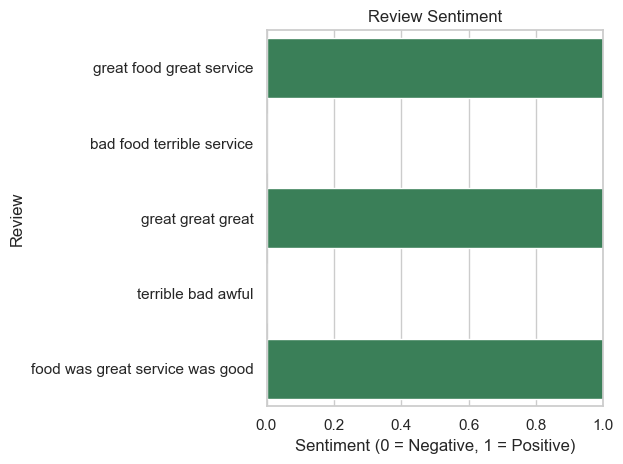

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

ax = sns.barplot(
    x=labels,
    y=reviews,
    hue=labels,
    palette={0: "tomato", 1: "seagreen"},
    legend=False
)

ax.set_title("Review Sentiment")
ax.set_xlabel("Sentiment (0 = Negative, 1 = Positive)")
ax.set_ylabel("Review")
ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()


In [14]:

# 3. Prepare the Model
# The Bernoulli model explicitly penalizes the score when expected words are missing (0s)
bernoulli_model = BernoulliNB(alpha=1.0)
bernoulli_model.fit(X_binary, labels)


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [16]:

# 4. Manual Input and Prediction
# Let's test a review that relies on ABSENCE.
# It doesn't have the word "bad", but it also completely lacks the word "great".
manual_review_binary = ["food was average"]
manual_bin_counts = binary_vectorizer.transform(manual_review_binary)

prediction = bernoulli_model.predict(manual_bin_counts)
probabilities = bernoulli_model.predict_proba(manual_bin_counts)

print("--- BERNOULLI PREDICTION RESULTS ---")
print(f"Input: {manual_review_binary[0]}")
print(f"Predicted Sentiment: {'Positive' if prediction[0] == 1 else 'Negative'}")
print(f"Probability [Negative, Positive]: {np.round(probabilities[0], 7)}")

--- BERNOULLI PREDICTION RESULTS ---
Input: food was average
Predicted Sentiment: Positive
Probability [Negative, Positive]: [0.1104598 0.8895402]
